### Name: Neel Narvekar 
### Roll No.: 49
### PID: 246041
### Date: 16/03/2026
### Subject: ML
### Expt.-9: Apply PCA and LDA to reduce dataset dimensions

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time 

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
iris=datasets.load_iris()
x=iris.data
y=iris.target

feature_name=iris.feature_names
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [9]:
print("DATA SUMMARY")
print("No. of sample:",x.shape[0])
print("No. of features:",x.shape[1])
print("No. of classes:", len(np.unique(y)))
print(feature_name)

DATA SUMMARY
No. of sample: 150
No. of features: 4
No. of classes: 3
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [13]:
df=pd.DataFrame(x, columns=feature_name)

print("FEATURE STATISTICS")
stats_table = pd.DataFrame({
    "Mean":df.mean(),
    "Standard Deviation":df.std()
        })
print(stats_table)
print()
print(df.head())


FEATURE STATISTICS
                       Mean  Standard Deviation
sepal length (cm)  5.843333            0.828066
sepal width (cm)   3.057333            0.435866
petal length (cm)  3.758000            1.765298
petal width (cm)   1.199333            0.762238

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


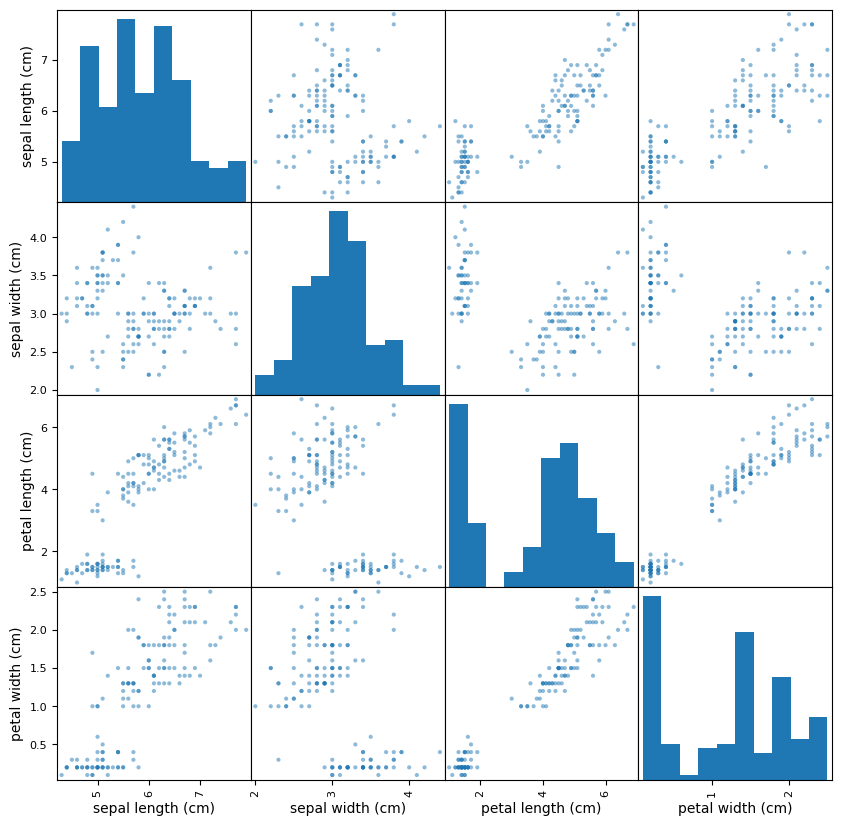

In [14]:
pd.plotting.scatter_matrix(
    df.iloc[:,0:4],
    figsize=(10,10),
    diagonal='hist'
)
plt.show()

In [16]:
sc=StandardScaler()
x_scaled= sc.fit_transform(x)

In [17]:
pca= PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

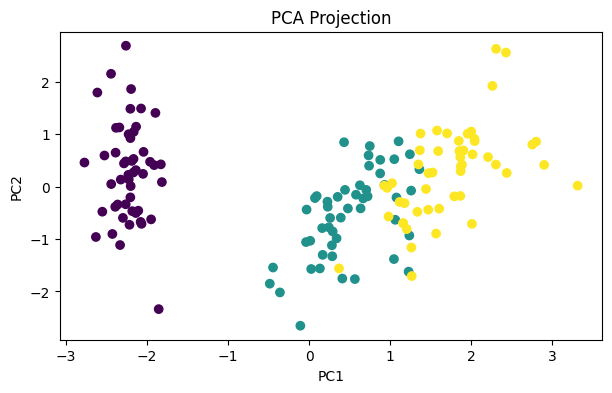

In [23]:
plt.figure(figsize=(7,4))
plt.scatter(x_pca[:,0],x_pca[:,1],c=y)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [24]:
explained_variance=pca.explained_variance_
variance_ratio=pca.explained_variance_ratio_
cumulative_vaiance=np.cumsum(variance_ratio)

In [25]:
pca_table =pd.DataFrame({
    "Eigenvalue":explained_variance,
    "Explained Variance(%)":variance_ratio*100,
    "Cumlative Variance(%)": cumulative_vaiance*100
})

print("PCA VARIANCE TABLE")
print(pca_table)
print()

PCA VARIANCE TABLE
   Eigenvalue  Explained Variance(%)  Cumlative Variance(%)
0    2.938085              72.962445              72.962445
1    0.920165              22.850762              95.813207



## PART IV 

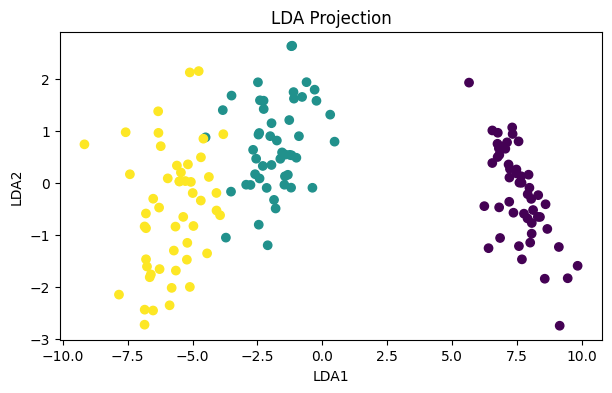

In [30]:
lda=LinearDiscriminantAnalysis(n_components=2)
x_lda=lda.fit_transform(x_scaled,y)

plt.figure(figsize=(7,4))
plt.scatter(x_lda[:,0],x_lda[:,1],c=y)
plt.title("LDA Projection")
plt.xlabel("LDA1")
plt.ylabel("LDA2")
plt.show()

In [32]:
x_train, x_test, y_train, y_test=train_test_split(x_scaled,y, test_size=0.3, random_state=42)

In [35]:
xp_train, xp_test, yp_train, yp_test=train_test_split(x_pca,y, test_size=0.3, random_state=42)

In [36]:
xl_train, xl_test, yl_train, yl_test=train_test_split(x_lda,y, test_size=0.3, random_state=42)

In [42]:
model= KNeighborsClassifier()

start=time.time()
model.fit(x_train,y_train)
train_time_original=time.time()-start

y_pred=model.predict(x_test)
acc_original=accuracy_score(y_test,y_pred)

start=time.time()
model.fit(xp_train,yp_train)
train_time_pca=time.time()-start

y_perd=model.predict(xp_test)
acc_pca=accuracy_score(y_test, y_perd)


In [43]:
start=time.time()
model.fit(xl_train,yl_train)
train_time_lda=time.time()-start

y_perd=model.predict(xp_test)
acc_lda=accuracy_score(y_test, y_perd)


In [44]:
accuracy_table=pd.DataFrame({
    "Dataset version":["Original","PCA Reduced","LDA Reduced"],
    "Accuracy":[acc_original,acc_pca,acc_lda],
    "Training Time(seconds)":[train_time_original,train_time_pca,train_time_lda]})

print("MODEL PERFORMANCE TABLE")
print(accuracy_table)
    

MODEL PERFORMANCE TABLE
  Dataset version  Accuracy  Training Time(seconds)
0        Original  1.000000                0.000892
1     PCA Reduced  0.955556                0.000430
2     LDA Reduced  0.288889                0.000757
